In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# encoding='latin1' fixes the error ✅
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data Types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df['Month_Year'] = df['Order Date'].dt.to_period('M')

print("Dates fixed! ✅")
df[['Order Date', 'Ship Date', 'Month', 'Year']].head()

Dates fixed! ✅


,Order Date,Ship Date,Month,Year
0,2016-11-08,2016-11-11,11,2016
1,2016-11-08,2016-11-11,11,2016
2,2016-06-12,2016-06-16,6,2016
3,2015-10-11,2015-10-18,10,2015
4,2015-10-11,2015-10-18,10,2015


In [4]:
print("=== KEY BUSINESS SUMMARY ===")
print(f"Total Sales   : ${df['Sales'].sum():,.2f}")
print(f"Total Profit  : ${df['Profit'].sum():,.2f}")
print(f"Total Orders  : {df['Order ID'].nunique()}")
print(f"Profit Margin : {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%")
print(f"Total Customers: {df['Customer Name'].nunique()}")

=== KEY BUSINESS SUMMARY ===
Total Sales   : $2,297,200.86
Total Profit  : $286,397.02
Total Orders  : 5009
Profit Margin : 12.47%
Total Customers: 793


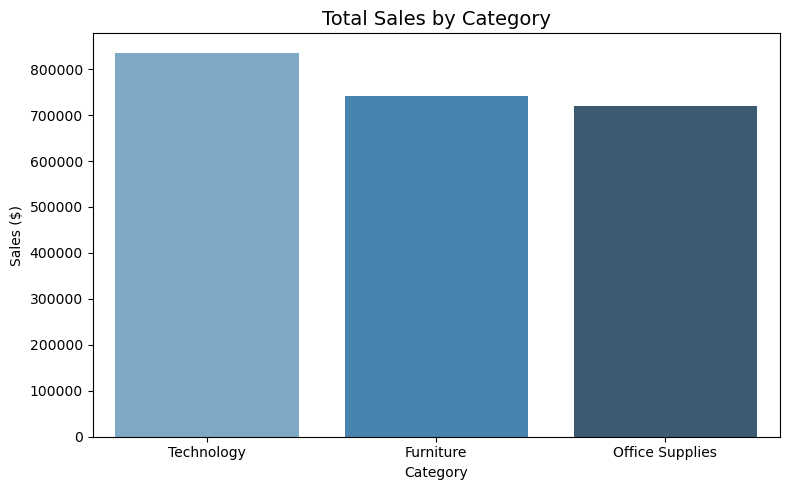

In [5]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values('Sales', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=category_sales, palette='Blues_d')
plt.title('Total Sales by Category', fontsize=14)
plt.ylabel('Sales ($)')
plt.xlabel('Category')
plt.tight_layout()
plt.show()

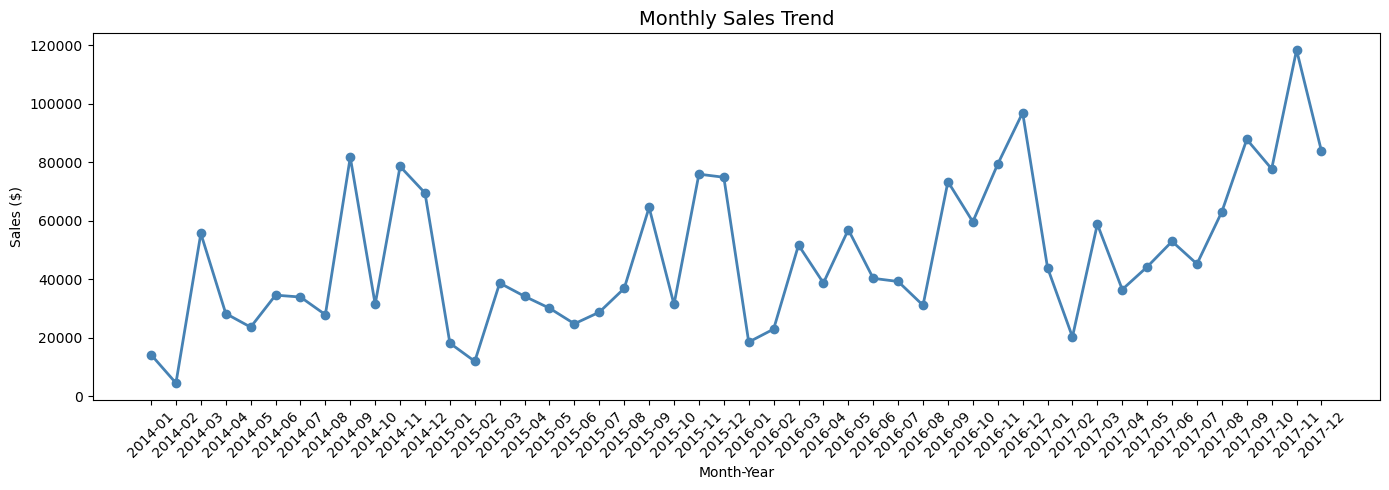

In [6]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['Month_Year'], monthly_sales['Sales'], 
         marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month-Year')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

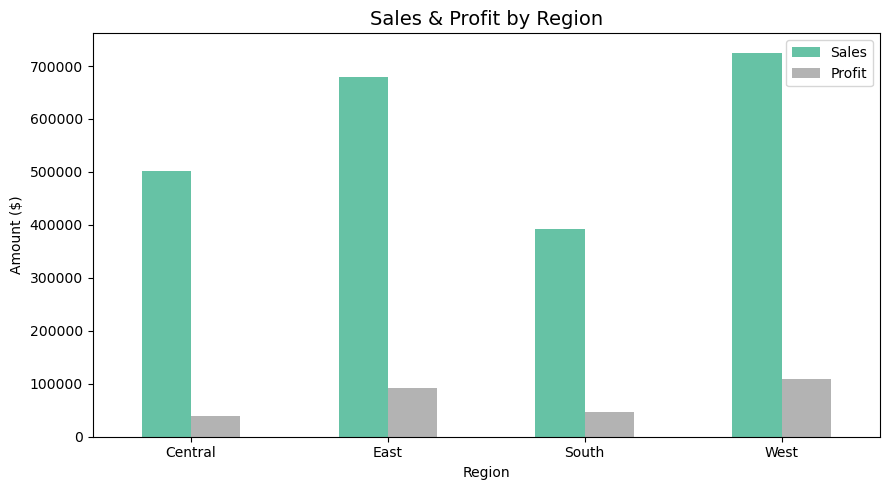

In [7]:
region_profit = df.groupby('Region')[['Sales','Profit']].sum().reset_index()

region_profit.plot(x='Region', kind='bar', figsize=(9,5), colormap='Set2')
plt.title('Sales & Profit by Region', fontsize=14)
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

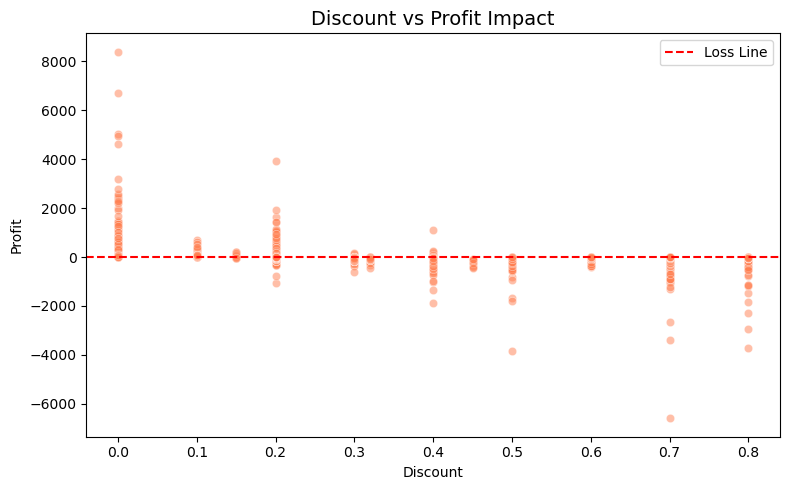

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.5, color='coral')
plt.axhline(0, color='red', linestyle='--', label='Loss Line')
plt.title('Discount vs Profit Impact', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

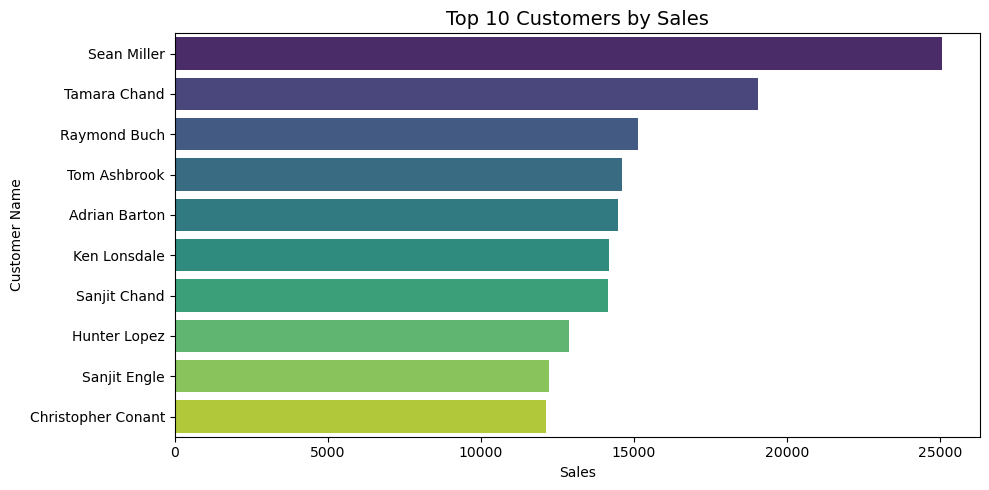

In [9]:
top_customers = df.groupby('Customer Name')['Sales'].sum()\
                  .reset_index()\
                  .sort_values('Sales', ascending=False)\
                  .head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='Sales', y='Customer Name', data=top_customers, palette='viridis')
plt.title('Top 10 Customers by Sales', fontsize=14)
plt.tight_layout()
plt.show()

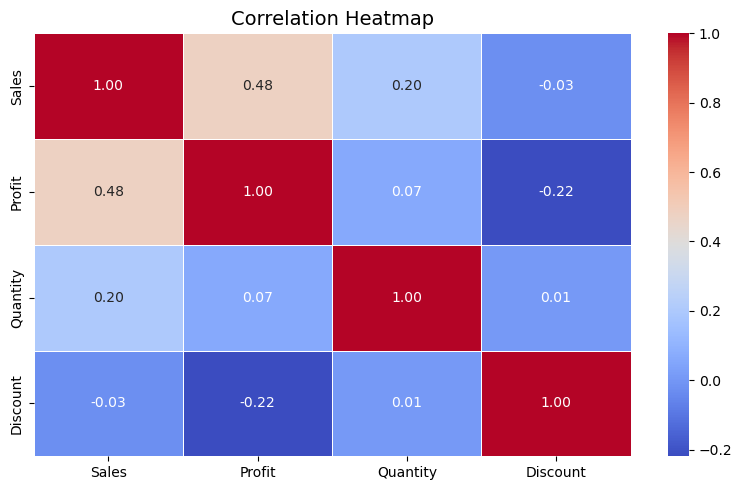

In [10]:
plt.figure(figsize=(8,5))
corr = df[['Sales', 'Profit', 'Quantity', 'Discount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

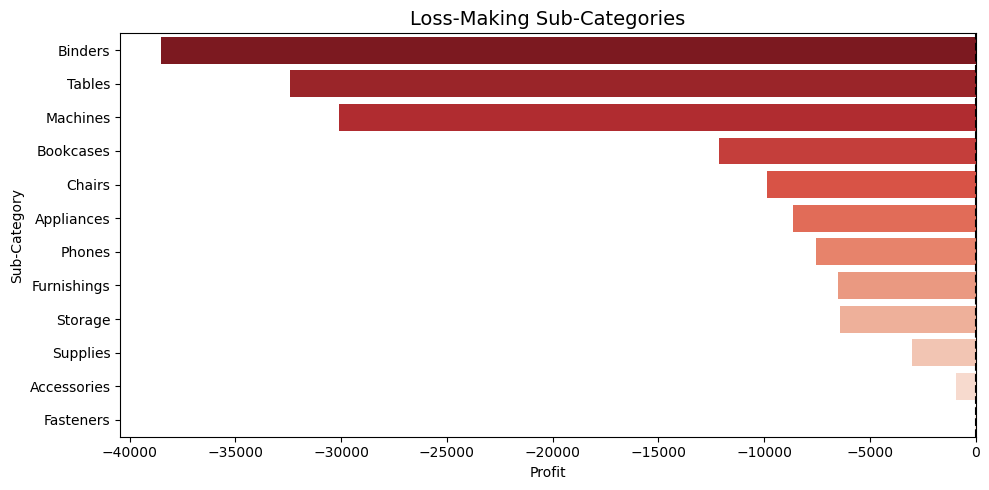

In [11]:
loss_products = df[df['Profit'] < 0]\
                .groupby('Sub-Category')['Profit'].sum()\
                .reset_index()\
                .sort_values('Profit')

plt.figure(figsize=(10,5))
sns.barplot(x='Profit', y='Sub-Category', data=loss_products, palette='Reds_r')
plt.axvline(0, color='black', linestyle='--')
plt.title('Loss-Making Sub-Categories', fontsize=14)
plt.tight_layout()
plt.show()

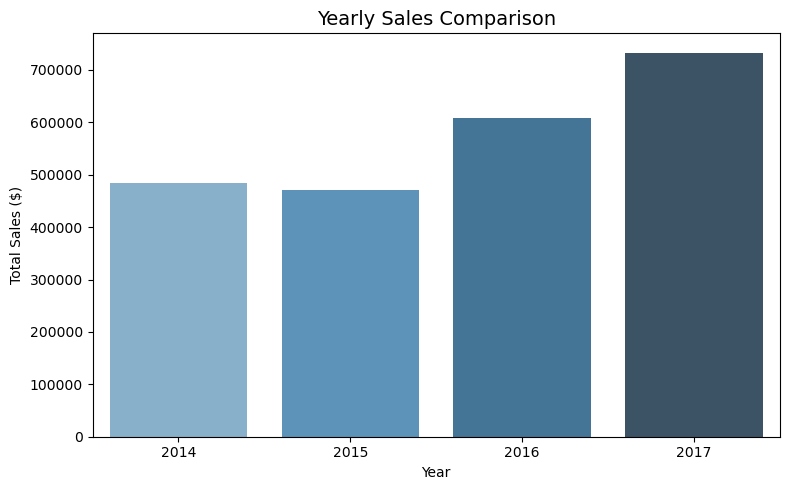

In [12]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Year', y='Sales', data=yearly_sales, palette='Blues_d')
plt.title('Yearly Sales Comparison', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

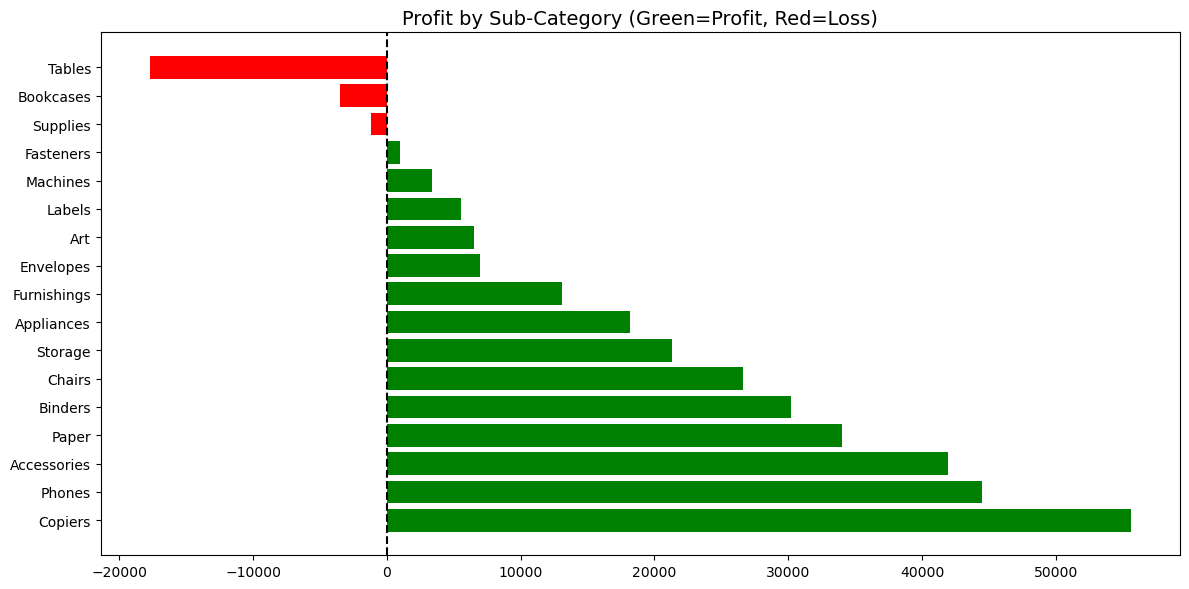

In [13]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum()\
               .reset_index()\
               .sort_values('Profit', ascending=False)

plt.figure(figsize=(12,6))
colors = ['green' if x > 0 else 'red' for x in sub_profit['Profit']]
plt.barh(sub_profit['Sub-Category'], sub_profit['Profit'], color=colors)
plt.axvline(0, color='black', linestyle='--')
plt.title('Profit by Sub-Category (Green=Profit, Red=Loss)', fontsize=14)
plt.tight_layout()
plt.show()

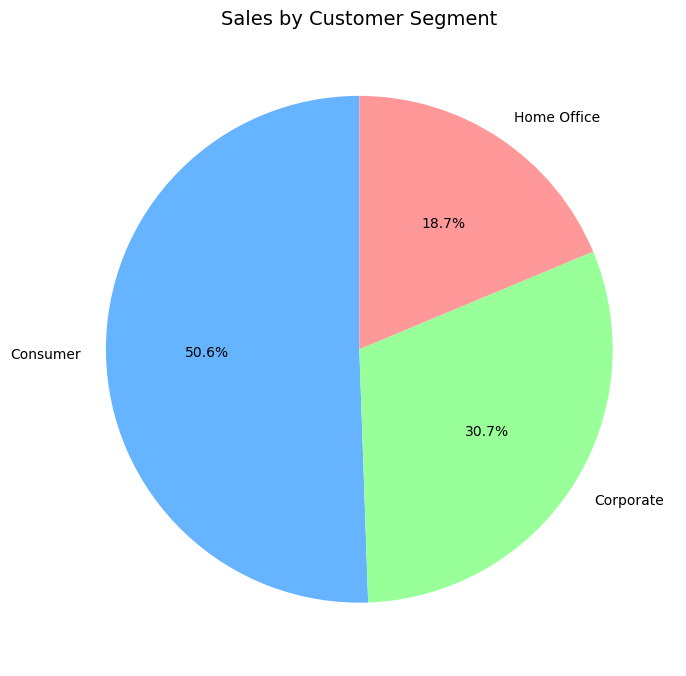

In [14]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(7,7))
plt.pie(segment_sales, labels=segment_sales.index, 
        autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'],
        startangle=90)
plt.title('Sales by Customer Segment', fontsize=14)
plt.tight_layout()
plt.show()

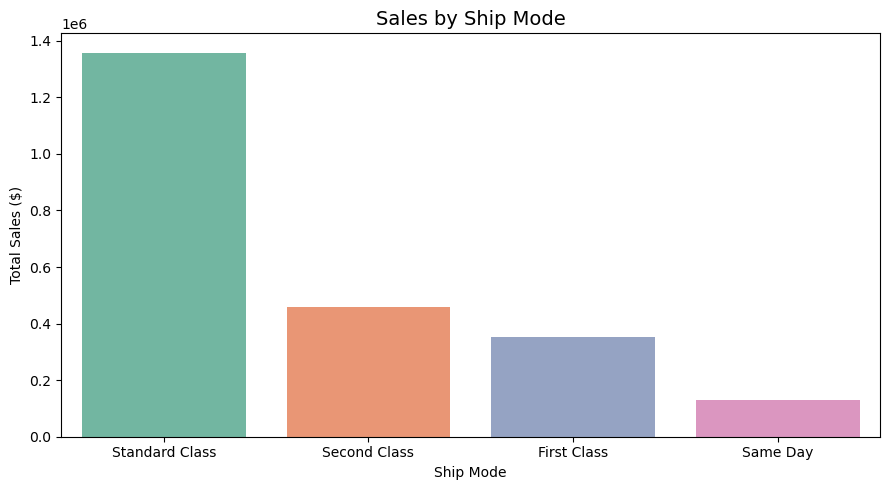

In [15]:
ship_sales = df.groupby('Ship Mode')['Sales'].sum()\
               .reset_index()\
               .sort_values('Sales', ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x='Ship Mode', y='Sales', data=ship_sales, palette='Set2')
plt.title('Sales by Ship Mode', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()